In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("../data/Unemployment in India copy.csv")

In [20]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [21]:
df.shape

(768, 7)

In [22]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [24]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [25]:
df.columns = df.columns.str.strip()

In [26]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [27]:
df = df.dropna()

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df = df.drop_duplicates()

In [30]:
df.shape

(740, 7)

In [31]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [32]:
df['Year'] = df['Date'].dt.year

In [33]:
df['Month'] = df['Date'].dt.month

In [34]:
df['Month_Name'] = df['Date'].dt.month_name()

In [35]:
df.shape

(740, 10)

In [36]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,September


In [37]:
df.to_csv("../data/cleaned_unemployment.csv", index=False)

In [38]:
df['Estimated Unemployment Rate (%)'].mean()

np.float64(11.787945945945946)

In [39]:
df['Estimated Unemployment Rate (%)'].median()

np.float64(8.35)

In [40]:
df['Estimated Unemployment Rate (%)'].min()

np.float64(0.0)

In [41]:
df['Estimated Unemployment Rate (%)'].max()

np.float64(76.74)

In [42]:
df.loc[df['Estimated Unemployment Rate (%)'].idxmax()]

Region                                              Puducherry
Date                                       2020-04-30 00:00:00
Frequency                                              Monthly
Estimated Unemployment Rate (%)                          76.74
Estimated Employed                                     68122.0
Estimated Labour Participation Rate (%)                  35.54
Area                                                     Urban
Year                                                      2020
Month                                                        4
Month_Name                                               April
Name: 627, dtype: object

In [43]:
monthly_trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

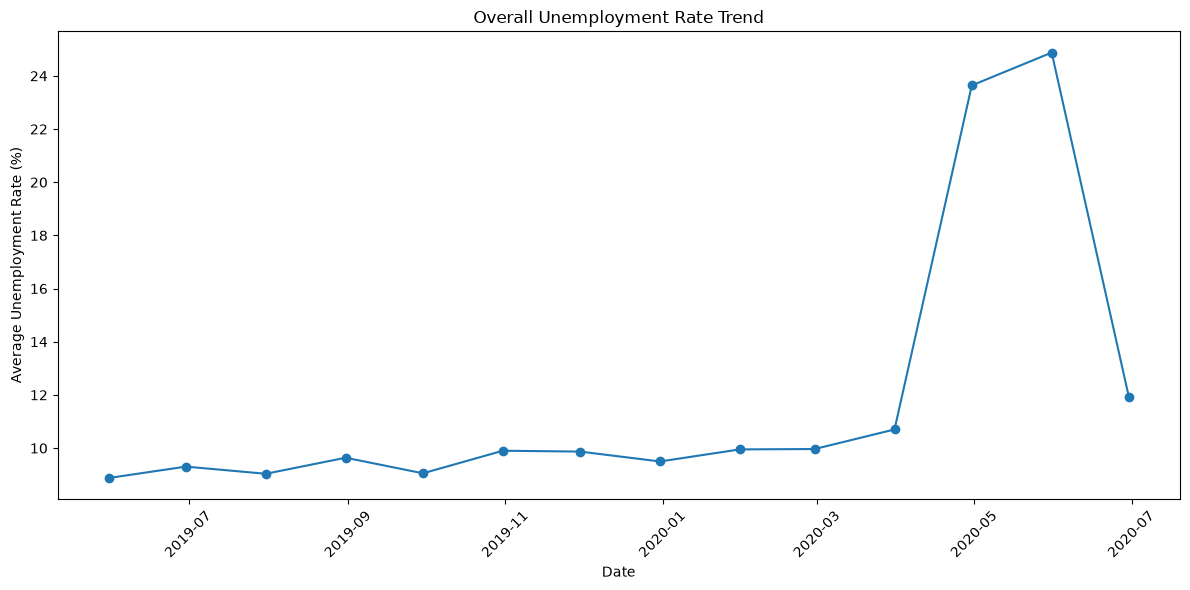

In [47]:
monthly_trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_trend.index, monthly_trend.values, marker='o')

plt.title('Overall Unemployment Rate Trend')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visualization/unemployment_trend.png")
plt.show()

In [48]:
pre_covid = df[df['Date'] < '2020-03-01']

covid_period = df[
    (df['Date'] >= '2020-03-01') &
    (df['Date'] <= '2020-06-30')
]

before_covid_avg = pre_covid['Estimated Unemployment Rate (%)'].mean()
covid_avg = covid_period['Estimated Unemployment Rate (%)'].mean()

increase = covid_avg - before_covid_avg

print("Before COVID average:", round(before_covid_avg, 2), "%")
print("COVID period average:", round(covid_avg, 2), "%")
print("Increase during COVID period:", round(increase, 2), "percentage points")

Before COVID average: 9.51 %
COVID period average: 17.77 %
Increase during COVID period: 8.26 percentage points


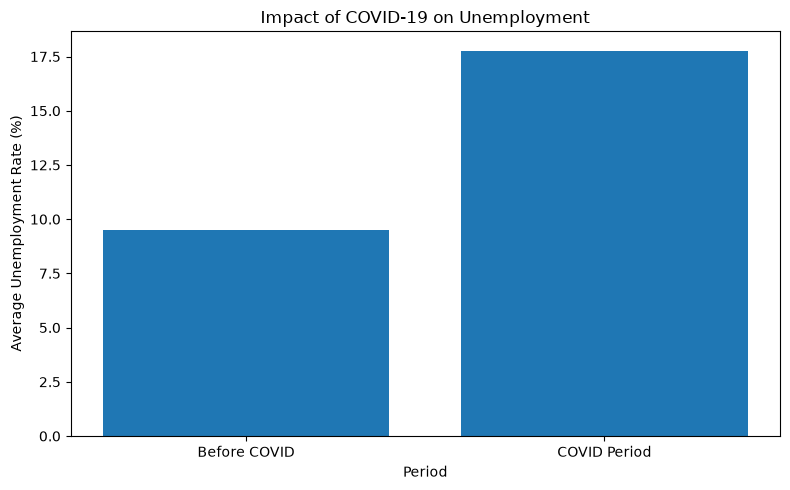

In [49]:
covid_comparison = pd.Series({
    'Before COVID': before_covid_avg,
    'COVID Period': covid_avg
})

plt.figure(figsize=(8, 5))
plt.bar(covid_comparison.index, covid_comparison.values)

plt.title('Impact of COVID-19 on Unemployment')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.savefig("../visualization/covid_impact.png")
plt.show()

In [50]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

region_avg = region_avg.sort_values(ascending=False)

top_regions = region_avg.head(10)

print("Top 10 regions by average unemployment rate:")
print(top_regions)

Top 10 regions by average unemployment rate:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


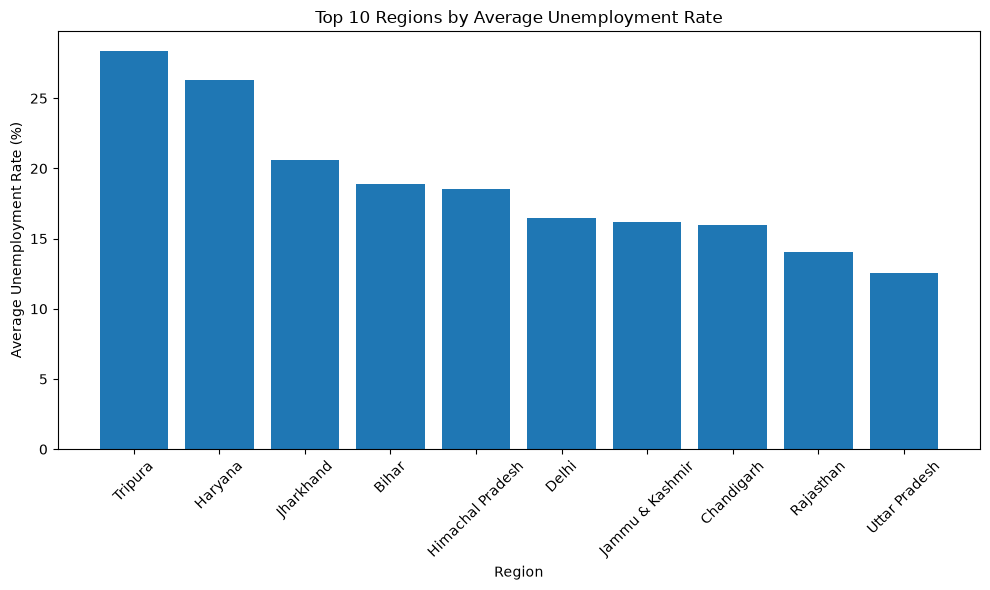

In [51]:
plt.figure(figsize=(10, 6))

plt.bar(top_regions.index, top_regions.values)

plt.title('Top 10 Regions by Average Unemployment Rate')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visualization/regional_analysis.png")
plt.show()

In [52]:
monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

print("Average unemployment rate by month:")
print(monthly_avg)

Average unemployment rate by month:
Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64


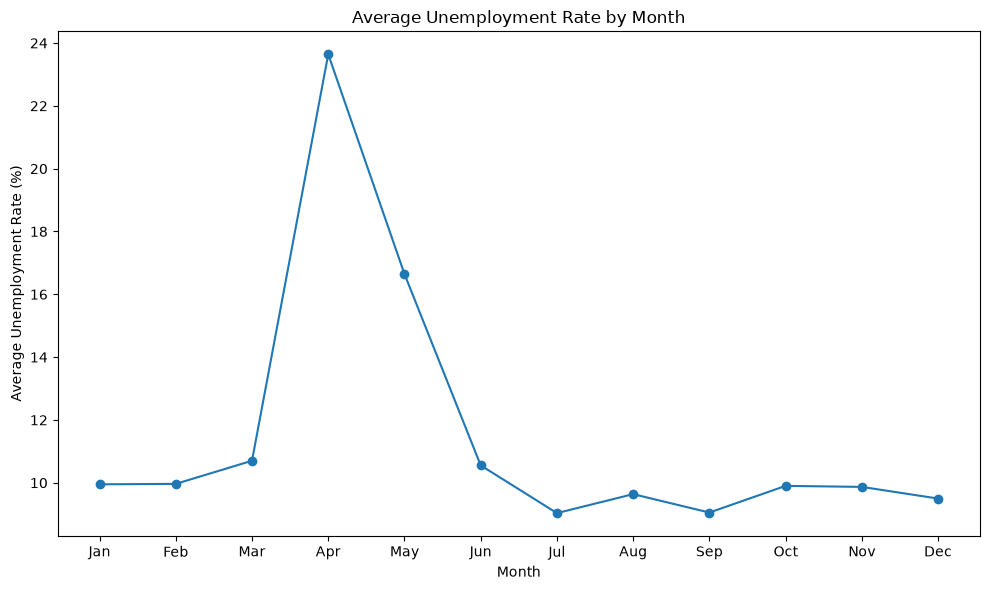

In [53]:
plt.figure(figsize=(10, 6))

plt.plot(monthly_avg.index, monthly_avg.values, marker='o')

plt.title('Average Unemployment Rate by Month')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(
    range(1, 13),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)

plt.tight_layout()
plt.savefig("../visualization/seasonal_analysis.png")
plt.show()

In [54]:
area_avg = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

print("Average unemployment rate by area:")
print(area_avg)

Average unemployment rate by area:
Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


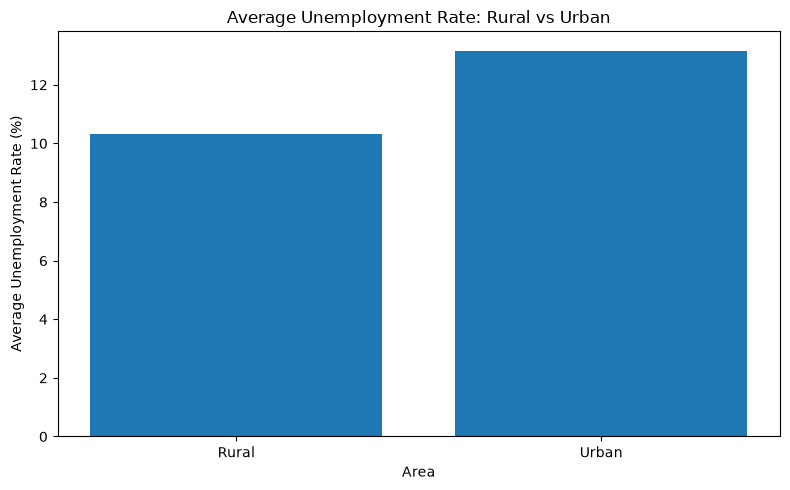

In [55]:
plt.figure(figsize=(8, 5))

plt.bar(area_avg.index, area_avg.values)

plt.title('Average Unemployment Rate: Rural vs Urban')
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.savefig("../visualization/rural_urban_analysis.png")
plt.show()

In [56]:
correlation = df.corr(numeric_only=True)

print(correlation)

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   
Year                                                            0.262602   
Month                                                          -0.122938   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   
Year                                              -0.031841   
Month                                              0.011285   

                                         Estimated Labour Participation Rate (%)  \
Estimated Unemployment Rate (%)                                         0.002558

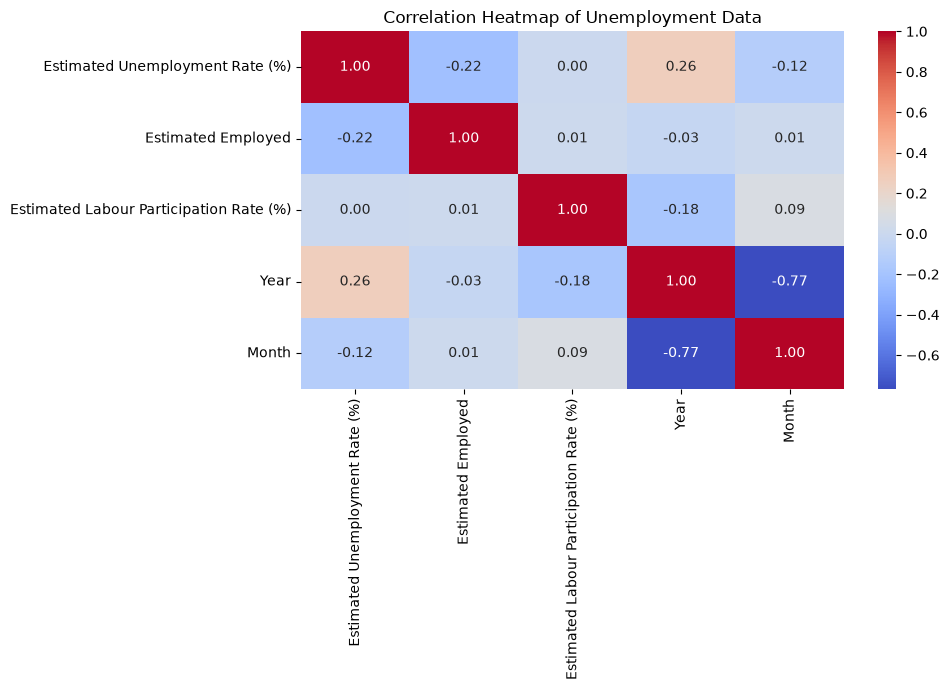

In [57]:
plt.figure(figsize=(10, 7))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Unemployment Data')
plt.tight_layout()

plt.savefig("../visualization/correlation_heatmap.png")
plt.show()

## Final Project Findings

### 1. Overall Unemployment
- Average unemployment rate: 11.79%
- Median unemployment rate: 8.35%
- Minimum unemployment rate: 0%
- Maximum unemployment rate: 76.74%

### 2. COVID-19 Impact
- Before COVID average: 9.51%
- COVID period average: 17.77%
- Increase: 8.26 percentage points

### 3. Monthly Pattern
- Highest monthly average: April – 23.64%
- Lowest monthly average: July – 9.03%

### 4. Regional Analysis
- Tripura recorded the highest regional average unemployment rate: 28.35%

### 5. Rural vs Urban
- The analysis shows differences in average unemployment rates between rural and urban areas.

### 6. Correlation Analysis
- A correlation heatmap was used to study relationships between numerical variables.

## Conclusion

The analysis shows significant variation in unemployment rates across time and regions in India.

The cleaned dataset had an average unemployment rate of 11.79%. Unemployment increased considerably during the COVID-19 period, from 9.51% before COVID to 17.77% during March–June 2020.

April recorded the highest monthly average unemployment rate of 23.64%, while July recorded the lowest at 9.03%. Regional differences were also observed, with Tripura having the highest average unemployment rate in the analyzed dataset.

Overall, the project demonstrates how Python, Pandas, Matplotlib, and Seaborn can be used for data cleaning, analysis, visualization, and identifying important unemployment trends.